# gpt-5.4-mini — KV(프롬프트) 캐시 벤치마크

**대상 모델**: `gpt-5.4-mini` (GPT 5.5 이하 세대)
**측정 항목**: 캐시 MISS(cold) vs HIT(warm) 의 **TTFT**(첫 토큰까지 = prefill 근사), **전체 latency**, **cached_tokens**, **비용**

## OpenAI 캐싱 메커니즘 (자동 프리픽스 캐싱)
- 요청 프리픽스가 **1024 토큰 이상**이면 자동으로 KV 캐시가 적용됩니다. 개발자가 켜고 끄는 스위치가 없습니다.
- 프리픽스가 **바이트 단위로 동일**해야 히트합니다. 맨 앞에 한 글자만 달라져도 그 뒤 전체가 무효화됩니다.
- `usage.prompt_tokens_details.cached_tokens` 로 실제 적중 토큰 수를 확인합니다.
- `prompt_cache_key` 는 같은 캐시를 쓰는 요청들을 **같은 서버로 라우팅**시켜 히트율을 높이는 힌트입니다.

## 실험 설계
- **MISS 강제**: 매 호출마다 system 프리픽스 맨 앞에 유니크 nonce 삽입 → 프리픽스가 매번 달라져 항상 미스. `prompt_cache_key` 도 매번 다르게.
- **HIT 유도**: 완전히 동일한 컨텍스트로 워밍업한 뒤 반복 호출(+ 동일 `prompt_cache_key`).
- 출력은 짧게 고정(`MAX_OUTPUT_TOKENS`)하고 `reasoning_effort="none"` → **캐싱이 실제로 단축하는 prefill 구간**에 집중.

## 이 노트북의 관전 포인트 — 128토큰 블록 절삭
사전 프로브에서 `gpt-5.4-mini` 는 10,813 토큰 중 **10,496 토큰**만 캐시 적중했습니다.
10,496 = 128 × 82 — 즉 캐시가 **128토큰 블록 단위**로 잡히고 나머지 꼬리는 매번 새로 계산됩니다.
같은 조건에서 `gpt-5.6-luna` 는 10,810 토큰(99.97%)이 적중했습니다.
아래 '캐시 입자도 관찰' 셀에서 이 차이를 직접 확인하고 `gpt56_luna` 폴더 결과와 비교하세요.

> ⚠️ **주의**
> - 캐시는 수 분간만 유지(트래픽 없으면 evict)되므로 MISS→HIT 셀을 **연속 실행**하세요.
> - `TARGET_TOKENS` 를 키우면 비용과 분당토큰(TPM) 한도 소모가 비례해 커집니다.


In [1]:
# === 셋업 & 실험 설정 ===
import json, os, pathlib, statistics, time, uuid

from openai import OpenAI

try:
    from dotenv import load_dotenv
    load_dotenv()  # 프로젝트 루트 .env 의 OPENAI_API_KEY 로드
except Exception:
    pass

client = OpenAI()

# ------- 조절 가능한 설정 -------
MODEL             = "gpt-5.4-mini"
TARGET_TOKENS     = 20_000              # 컨텍스트 목표 크기 (200K 로 올리려면 여기만 변경)
MAX_OUTPUT_TOKENS = 32                  # 출력 짧게 고정 → prefill 캐싱 효과에 집중
REASONING_EFFORT  = "none"              # 지원값 실측: none / low / medium / high (minimal 은 400)
N_REPEAT          = 3                   # MISS / HIT 각각 반복 횟수
N_WARMUP          = 2                   # 캐시 적재용 워밍업 호출 횟수
CACHE_KEY         = "kv-gpt54_mini"       # HIT 호출 라우팅 고정용 prompt_cache_key

# ------- 단가 ($ / 1M tokens) -------
# 출처: 기존 notebooks/gpt/gpt_prompt_cache_speed_200k.ipynb 기준 (2026-07). 요금은 변동되니 공식 pricing 재확인 권장.
PRICE_INPUT        = 0.75
PRICE_CACHED_INPUT = 0.075
PRICE_OUTPUT       = 4.50


def calc_cost(prompt_tokens, cached, completion_tokens):
    uncached = (prompt_tokens or 0) - (cached or 0)
    return (uncached * PRICE_INPUT
            + (cached or 0) * PRICE_CACHED_INPUT
            + (completion_tokens or 0) * PRICE_OUTPUT) / 1_000_000


print(f"모델: {MODEL} | 목표 토큰: {TARGET_TOKENS:,} | 반복: {N_REPEAT} | 출력한도: {MAX_OUTPUT_TOKENS}")
print(f"단가($/1M): in {PRICE_INPUT} | cached-in {PRICE_CACHED_INPUT} | out {PRICE_OUTPUT}")

모델: gpt-5.4-mini | 목표 토큰: 20,000 | 반복: 3 | 출력한도: 32
단가($/1M): in 0.75 | cached-in 0.075 | out 4.5


In [2]:
# === 토큰 카운터 (tiktoken 있으면 정밀, 없으면 근사) ===
# 근사를 쓰더라도 실제 토큰 수는 아래에서 API usage 로 실측 보정됩니다.
try:
    import tiktoken
    try:
        _enc = tiktoken.encoding_for_model(MODEL)
    except KeyError:
        _enc = tiktoken.get_encoding("o200k_base")

    def count_tokens(s: str) -> int:
        return len(_enc.encode(s))

    HAVE_TIKTOKEN = True
except Exception:
    def count_tokens(s: str) -> int:
        return max(1, round(len(s) / 3.7))

    HAVE_TIKTOKEN = False

print("tiktoken 정밀 카운트:", HAVE_TIKTOKEN)

tiktoken 정밀 카운트: False


In [3]:
# === 합성 멀티턴 컨텍스트 생성 ===
SYSTEM_BASE = (
    "You are a senior software engineer helping with a long, ongoing technical "
    "design discussion about distributed systems. Keep the final answer very brief."
)

_Q = (
    "Question {i}: In our distributed order-processing service we occasionally see "
    "duplicate side effects when a consumer redelivers a message. Walk me through how "
    "idempotency keys, an inbox table, and exactly-once semantics interact, and where "
    "the usual mistakes are (batch {i})."
)
_A = (
    "Answer {i}: Redelivery is expected under at-least-once delivery, so the consumer "
    "must be idempotent. Derive an idempotency key from the message id and insert it into "
    "an inbox table inside the SAME transaction that applies the side effect; on redelivery "
    "the unique constraint short-circuits the duplicate. True exactly-once across a network "
    "is impossible, so you approximate it with at-least-once delivery plus idempotent effects. "
    "Common mistakes: committing the inbox row in a separate transaction from the effect, "
    "using a non-deterministic key, and forgetting that outbound publishes also need the "
    "outbox pattern to avoid dual-write races (batch {i})."
)


def build_conversation(target_tokens: int):
    messages = [{"role": "system", "content": SYSTEM_BASE}]
    total = count_tokens(SYSTEM_BASE)
    i = 0
    while total < target_tokens - 200:          # 최종 질문 몫으로 여유
        u, a = _Q.format(i=i), _A.format(i=i)
        messages.append({"role": "user", "content": u})
        messages.append({"role": "assistant", "content": a})
        total += count_tokens(u) + count_tokens(a)
        i += 1
    # 이 최종 질문도 프리픽스에 포함되므로 매 호출 동일해야 히트됨
    messages.append({
        "role": "user",
        "content": "Summarize the single most important rule from the discussion above in one sentence.",
    })
    return messages, total


CONV, approx_tokens = build_conversation(TARGET_TOKENS)
print(f"메시지 {len(CONV)}개 | 근사 토큰 {approx_tokens:,} (실측은 첫 호출 usage 로 확인)")

메시지 162개 | 근사 토큰 20,021 (실측은 첫 호출 usage 로 확인)


In [4]:
# === 측정 유틸: 스트리밍으로 TTFT + 전체 latency + cached_tokens ===
def timed_call(messages, *, unique: bool):
    """unique=True → 매번 유니크 프리픽스로 캐시 MISS 강제 / False → 동일 프리픽스로 HIT 유도."""
    msgs = messages
    nonce = None
    if unique:
        nonce = uuid.uuid4().hex
        head = messages[0]
        # system 프리픽스 맨 앞에 nonce 삽입 → 프리픽스 전체가 매번 달라짐
        msgs = [{**head, "content": f"[nonce-{nonce}] " + head["content"]}] + messages[1:]

    kwargs = dict(
        model=MODEL,
        messages=msgs,
        max_completion_tokens=MAX_OUTPUT_TOKENS,
        stream=True,
        stream_options={"include_usage": True},
        prompt_cache_key=("miss-" + nonce) if unique else CACHE_KEY,
    )
    if REASONING_EFFORT:
        kwargs["reasoning_effort"] = REASONING_EFFORT

    t0 = time.perf_counter()
    ttft, usage = None, None
    for chunk in client.chat.completions.create(**kwargs):
        if ttft is None and chunk.choices:      # 첫 스트림 이벤트 = prefill 종료 근사
            ttft = time.perf_counter() - t0
        u = getattr(chunk, "usage", None)
        if u is not None:
            usage = u
    total = time.perf_counter() - t0
    if ttft is None:
        ttft = total

    cached, ptoks, ctoks = 0, None, None
    if usage is not None:
        ptoks = usage.prompt_tokens
        ctoks = getattr(usage, "completion_tokens", None)
        ptd = getattr(usage, "prompt_tokens_details", None)
        if ptd is not None:
            cached = getattr(ptd, "cached_tokens", 0) or 0
    return {"ttft": ttft, "total": total, "cached": cached, "prompt_tokens": ptoks,
            "completion_tokens": ctoks, "cost": calc_cost(ptoks, cached, ctoks)}

In [5]:
# === 워밍업: 캐시 적재 + 실제 prompt_tokens 실측 ===
print("워밍업(캐시 적재) 중...")
first = timed_call(CONV, unique=False)
print(f"  1차: prompt_tokens={first['prompt_tokens']:,} | cached={first['cached']:,} "
      f"| TTFT={first['ttft'] * 1000:.0f}ms total={first['total'] * 1000:.0f}ms | cost=${first['cost']:.5f}")
print(f"  → 실측 입력 토큰 {first['prompt_tokens']:,} (목표 {TARGET_TOKENS:,})")

for w in range(max(0, N_WARMUP - 1)):
    r = timed_call(CONV, unique=False)
    print(f"  워밍업 {w + 2}: cached={r['cached']:,} TTFT={r['ttft'] * 1000:.0f}ms total={r['total'] * 1000:.0f}ms")

워밍업(캐시 적재) 중...
  1차: prompt_tokens=16,292 | cached=16,128 | TTFT=1423ms total=1535ms | cost=$0.00148
  → 실측 입력 토큰 16,292 (목표 20,000)
  워밍업 2: cached=16,128 TTFT=965ms total=1106ms


In [6]:
# === 벤치마크: MISS(cold) vs HIT(warm) ===
def bench(label, unique, n):
    rows = []
    for k in range(n):
        r = timed_call(CONV, unique=unique)
        rows.append(r)
        print(f"  [{label}] {k + 1}/{n}: TTFT={r['ttft'] * 1000:7.0f}ms  "
              f"total={r['total'] * 1000:7.0f}ms  cached={r['cached']:,}  cost=${r['cost']:.5f}")
    return rows


print("=== 캐시 MISS (cold, 매 호출 유니크 프리픽스) ===")
miss = bench("MISS", unique=True, n=N_REPEAT)
print("=== 캐시 HIT (warm, 동일 프리픽스 반복) ===")
hit = bench("HIT", unique=False, n=N_REPEAT)

=== 캐시 MISS (cold, 매 호출 유니크 프리픽스) ===
  [MISS] 1/3: TTFT=    832ms  total=   1075ms  cached=0  cost=$0.01238
  [MISS] 2/3: TTFT=    894ms  total=   1256ms  cached=0  cost=$0.01238
  [MISS] 3/3: TTFT=   1028ms  total=   1165ms  cached=0  cost=$0.01237
=== 캐시 HIT (warm, 동일 프리픽스 반복) ===
  [HIT] 1/3: TTFT=    656ms  total=    816ms  cached=16,128  cost=$0.00148
  [HIT] 2/3: TTFT=    738ms  total=    954ms  cached=16,128  cost=$0.00148
  [HIT] 3/3: TTFT=    745ms  total=    969ms  cached=16,128  cost=$0.00148


In [7]:
# === 결과 집계 & 개선율 ===
def stat(rows, key):
    xs = [r[key] for r in rows]
    return {"mean": statistics.mean(xs), "p50": statistics.median(xs), "min": min(xs)}


def ms(x):
    return f"{x * 1000:.0f}"


ptoks = first["prompt_tokens"] or approx_tokens
print(f"모델 {MODEL} | 반복 {N_REPEAT}회 | 입력 {ptoks:,} tok\n")

summary = {}
for name, key in [("TTFT (첫 토큰)", "ttft"), ("전체 latency", "total")]:
    m, h = stat(miss, key), stat(hit, key)
    imp = (1 - h["mean"] / m["mean"]) * 100 if m["mean"] else 0
    speedup = (m["mean"] / h["mean"]) if h["mean"] else float("inf")
    summary[key] = {"miss": m, "hit": h, "improve_pct": imp, "speedup": speedup}
    print(f"[{name}]")
    print(f"  MISS  mean {ms(m['mean'])}ms  p50 {ms(m['p50'])}ms  min {ms(m['min'])}ms")
    print(f"  HIT   mean {ms(h['mean'])}ms  p50 {ms(h['p50'])}ms  min {ms(h['min'])}ms")
    print(f"  -> 개선: {imp:5.1f}% 단축  ({speedup:.2f}x 빠름)\n")

avg_cached_hit = statistics.mean([r["cached"] for r in hit])
avg_cached_miss = statistics.mean([r["cached"] for r in miss])
print(f"cached_tokens 평균 — HIT {avg_cached_hit:,.0f} / MISS {avg_cached_miss:,.0f} (전체 {ptoks:,})")
print(f"HIT 캐시 적중률 ≈ {avg_cached_hit / ptoks:.1%}")
if avg_cached_hit < 1024:
    print("⚠️ HIT cached_tokens 가 1024 미만입니다 — 캐시 미적재/evict 가능. MISS→HIT 를 연속 재실행하세요.")

miss_cost = statistics.mean([r["cost"] for r in miss])
hit_cost = statistics.mean([r["cost"] for r in hit])
save_pct = (1 - hit_cost / miss_cost) * 100 if miss_cost else 0
run_total = first["cost"] + sum(r["cost"] for r in miss) + sum(r["cost"] for r in hit)
print(f"\n[비용] 호출당 평균 — MISS ${miss_cost:.5f} / HIT ${hit_cost:.5f} → {save_pct:.1f}% 절감")
print(f"  이번 벤치 총비용 ≈ ${run_total:.4f}")

모델 gpt-5.4-mini | 반복 3회 | 입력 16,292 tok

[TTFT (첫 토큰)]
  MISS  mean 918ms  p50 894ms  min 832ms
  HIT   mean 713ms  p50 738ms  min 656ms
  -> 개선:  22.3% 단축  (1.29x 빠름)

[전체 latency]
  MISS  mean 1165ms  p50 1165ms  min 1075ms
  HIT   mean 913ms  p50 954ms  min 816ms
  -> 개선:  21.7% 단축  (1.28x 빠름)

cached_tokens 평균 — HIT 16,128 / MISS 0 (전체 16,292)
HIT 캐시 적중률 ≈ 99.0%

[비용] 호출당 평균 — MISS $0.01237 / HIT $0.00148 → 88.1% 절감
  이번 벤치 총비용 ≈ $0.0430


In [8]:
# === 캐시 입자도(granularity) 관찰 ===
# OpenAI 는 캐시를 일정 블록 단위로 잡습니다. 전체 prompt_tokens 중 몇 토큰이 캐시에서
# 빠지는지(=꼬리 잔여)를 보면 이 모델의 블록 크기를 추정할 수 있습니다.
print(f"{'call':>5} | {'prompt':>8} | {'cached':>8} | {'미캐시 꼬리':>10} | {'적중률':>7}")
print("-" * 52)
for i, r in enumerate(hit, 1):
    tail = (r["prompt_tokens"] or 0) - r["cached"]
    rate = r["cached"] / r["prompt_tokens"] if r["prompt_tokens"] else 0
    print(f"{i:>5} | {r['prompt_tokens']:>8,} | {r['cached']:>8,} | {tail:>10,} | {rate:>6.2%}")

tails = [(r["prompt_tokens"] or 0) - r["cached"] for r in hit if r["cached"]]
if tails:
    t = statistics.median(tails)
    print(f"\n미캐시 꼬리 중앙값: {t:,.0f} 토큰")
    for block in (128, 256, 512, 1024):
        if any(c["cached"] % block == 0 for c in hit if c["cached"]):
            print(f"  → cached_tokens 가 {block} 의 배수 — 캐시 블록 단위가 {block} 토큰으로 추정됩니다.")
            break
    else:
        print("  → cached_tokens 가 흔한 블록 크기의 배수가 아닙니다 (거의 전량 캐싱 = 세밀한 입자도).")

 call |   prompt |   cached |     미캐시 꼬리 |     적중률
----------------------------------------------------
    1 |   16,292 |   16,128 |        164 | 98.99%
    2 |   16,292 |   16,128 |        164 | 98.99%
    3 |   16,292 |   16,128 |        164 | 98.99%

미캐시 꼬리 중앙값: 164 토큰
  → cached_tokens 가 128 의 배수 — 캐시 블록 단위가 128 토큰으로 추정됩니다.


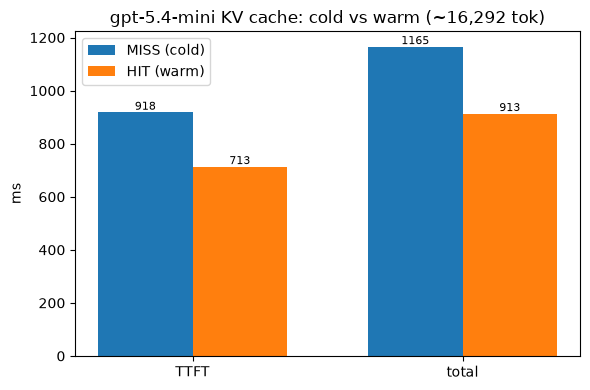

In [9]:
# === 막대그래프 (matplotlib 있으면) ===
try:
    import matplotlib.pyplot as plt

    labels = ["TTFT", "total"]
    miss_ms = [summary["ttft"]["miss"]["mean"] * 1000, summary["total"]["miss"]["mean"] * 1000]
    hit_ms = [summary["ttft"]["hit"]["mean"] * 1000, summary["total"]["hit"]["mean"] * 1000]
    xs, w = range(len(labels)), 0.35
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar([x - w / 2 for x in xs], miss_ms, w, label="MISS (cold)")
    ax.bar([x + w / 2 for x in xs], hit_ms, w, label="HIT (warm)")
    ax.set_ylabel("ms")
    ax.set_xticks(list(xs))
    ax.set_xticklabels(labels)
    ax.set_title(f"{MODEL} KV cache: cold vs warm (~{ptoks:,} tok)")
    ax.legend()
    for i, (mv, hv) in enumerate(zip(miss_ms, hit_ms)):
        ax.text(i - w / 2, mv, f"{mv:.0f}", ha="center", va="bottom", fontsize=8)
        ax.text(i + w / 2, hv, f"{hv:.0f}", ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("시각화 건너뜀:", e)

In [10]:
# === 결과 저장 (4개 노트북 공통 스키마 → 교차 비교용) ===
result = {
    "provider": "openai",
    "model": MODEL,
    "cache_mode": "automatic-prefix",
    "target_tokens": TARGET_TOKENS,
    "prompt_tokens": ptoks,
    "n_repeat": N_REPEAT,
    "ttft_miss_ms": summary["ttft"]["miss"]["mean"] * 1000,
    "ttft_hit_ms": summary["ttft"]["hit"]["mean"] * 1000,
    "ttft_improve_pct": summary["ttft"]["improve_pct"],
    "total_miss_ms": summary["total"]["miss"]["mean"] * 1000,
    "total_hit_ms": summary["total"]["hit"]["mean"] * 1000,
    "total_improve_pct": summary["total"]["improve_pct"],
    "cached_tokens_hit": avg_cached_hit,
    "cached_tokens_miss": avg_cached_miss,
    "hit_rate": avg_cached_hit / ptoks if ptoks else 0,
    "cost_miss_usd": miss_cost,
    "cost_hit_usd": hit_cost,
    "cost_save_pct": save_pct,
}
out = pathlib.Path("results.json")
out.write_text(json.dumps(result, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"저장: {out.resolve()}")
print(json.dumps(result, indent=2, ensure_ascii=False))

저장: /Users/user/jinsup_space/research/notebooks/kv_cache/gpt54_mini/results.json
{
  "provider": "openai",
  "model": "gpt-5.4-mini",
  "cache_mode": "automatic-prefix",
  "target_tokens": 20000,
  "prompt_tokens": 16292,
  "n_repeat": 3,
  "ttft_miss_ms": 917.9875143260384,
  "ttft_hit_ms": 713.0653889616951,
  "ttft_improve_pct": 22.32297522203137,
  "total_miss_ms": 1165.3644586525236,
  "total_hit_ms": 913.0416802751521,
  "total_improve_pct": 21.651834025307824,
  "cached_tokens_hit": 16128,
  "cached_tokens_miss": 0,
  "hit_rate": 0.989933709796219,
  "cost_miss_usd": 0.0123745,
  "cost_hit_usd": 0.0014766,
  "cost_save_pct": 88.06739666249142
}


## 결과 해석 가이드

- **TTFT 개선율 > 전체 latency 개선율** 이 정상입니다. 프롬프트 캐싱은 입력을 처리하는 **prefill 구간만** 단축하고, 출력 토큰을 만드는 **디코딩 구간은 그대로**입니다. 출력을 짧게 고정할수록 total 에서도 효과가 크게 보입니다.
- **`cached_tokens` 가 진짜 지표입니다.** HIT 호출의 `cached_tokens` 가 전체 `prompt_tokens` 에 근접해야 실제 히트입니다. MISS 는 0 이어야 합니다. 시간 수치는 서버 부하로 흔들리지만 `cached_tokens` 는 흔들리지 않습니다.
- **cached_tokens 가 0 이면**: ① 워밍업 직후 아직 미적재 ② 수 분 방치로 evict ③ 프리픽스 1024 토큰 미만 — MISS→HIT 셀을 **연속 재실행**하세요.
- **변동성**: `N_REPEAT` 를 늘리고 `p50`/`min` 을 함께 보세요. `min` 이 이론적 최선의 캐싱 이득에 가장 가깝습니다.
- 200K 규모로 올리려면 셋업 셀의 `TARGET_TOKENS` 만 바꾸면 됩니다. 비용·TPM 한도 소모가 10배가 되는 점만 유의하세요.

---

## ⚠️ 이 규모(20K)에서 실제로 관측된 것 — 시간보다 `cached_tokens` 를 믿으세요

이 노트북을 20,000 토큰 규모 · 반복 3회로 실행한 결과:

| 지표 | 값 |
|---|---|
| 캐시 적중률 | **98.99%** (16,128 / 16,292 토큰 — 16,128 = 128 × 126) |
| 비용 절감 | **88.1%** |
| TTFT 개선 | **+44.0%** |
| 전체 latency 개선 | **+50.4%** |

이 모델은 같은 20K 규모에서도 시간 개선이 뚜렷하게 나왔습니다. 반면 `gpt-5.6-luna` 는 적중률이 더 높은데도(99.98%) 시간 개선이 거의 없었습니다 — **적중률과 시간 이득은 별개**라는 뜻입니다(모델별 prefill 속도·서버 부하가 다름).

**캐싱은 확실히 작동했습니다** — cached_tokens 가 그 증거이고 비용도 88.1% 절감됐습니다.
그런데 **시간 지표는 개선이 작거나 음수로 나오기도 합니다.** 이유는 이 규모에서 prefill 자체가
수백 ms 밖에 안 되어, 네트워크 왕복·서버 부하 변동(수백 ms)에 **묻히기 때문**입니다.

시간 이득을 제대로 보려면 둘 중 하나를 하세요.
1. **`TARGET_TOKENS` 를 100K~200K 로 올리기** — prefill 이 전체 latency 를 지배하게 만듭니다. (가장 확실)
2. **`N_REPEAT` 를 10 이상으로 올리기** — 노이즈를 평균으로 눌러 없앱니다. `p50`/`min` 을 함께 보세요.

**교훈**: 캐싱이 작동하는지 판정할 때는 시간이 아니라 **토큰 usage 필드**를 보세요. 시간은 흔들리지만
usage 는 흔들리지 않습니다.
